In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU is still not enabled")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
!pip install -q -U transformers diffusers accelerate gTTS sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 93.3 MB/s eta 0:00:00


SYSTEM INFORMATION
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

Enter your topic: The benefits of renewable energy

Selected topic:
The benefits of renewable energy

GENERATING TEXT...
Loading FLAN-T5 model...


tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Stable Diffusion loaded successfully.

GENERATING IMAGE...


  0%|          | 0/25 [00:00<?, ?it/s]


Image generated successfully!
Image saved to: /content/content_image.png


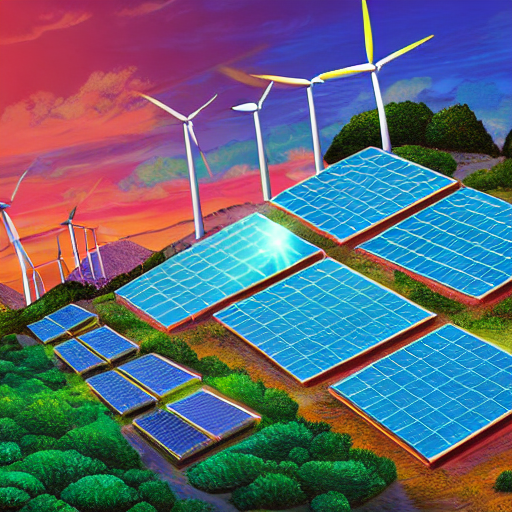


GENERATING AUDIO...

Audio generated successfully!
Audio saved to: /content/content_audio.mp3

GENERATED AUDIO



FINAL MULTIMEDIA CONTENT PACKAGE

TOPIC:
The benefits of renewable energy

GENERATED TEXT:
/media/what_film_s/relation_dopinion_title_film_non_the_film_film_film_art_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_film_

GENERATED IMAGE:
/content/content_image.png

GENERATED AUDIO:
/content/content_audio.mp3

CONTENT GENERATION COMPLETED SUCCESSFULLY!


In [6]:
# ============================================================
# AI-BASED CONTENT GENERATION SYSTEM
# TEXT + IMAGE + AUDIO
# GOOGLE COLAB / NVIDIA T4
# ============================================================

import os
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

from diffusers import StableDiffusionPipeline
from gtts import gTTS

from IPython.display import display, Audio


# ============================================================
# STEP 1: CHECK GPU
# ============================================================

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is not available. "
        "Please select T4 GPU from Runtime > Change runtime type."
    )

device = torch.device("cuda")

print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# STEP 2: USER INPUT
# ============================================================

topic = input("\nEnter your topic: ")

print("\nSelected topic:")
print(topic)


# ============================================================
# STEP 3: TEXT GENERATION USING FLAN-T5
# ============================================================

print("\n" + "=" * 60)
print("GENERATING TEXT...")
print("=" * 60)

text_model_name = "google/flan-t5-base"

print("Loading FLAN-T5 model...")

tokenizer = AutoTokenizer.from_pretrained(
    text_model_name
)

text_model = AutoModelForSeq2SeqLM.from_pretrained(
    text_model_name,
    torch_dtype=torch.float16
)

text_model = text_model.to(device)

print("FLAN-T5 loaded successfully.")


# ------------------------------------------------------------
# Create prompt
# ------------------------------------------------------------

text_prompt = f"""
Write a short, engaging paragraph of about 50 to 80 words
about the following topic:

{topic}

The paragraph should be informative, clear, and suitable
for educational or social-media content.
"""


# ------------------------------------------------------------
# Tokenize input
# ------------------------------------------------------------

inputs = tokenizer(
    text_prompt,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

# Move tensors to GPU
inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}


# ------------------------------------------------------------
# Generate text
# ------------------------------------------------------------

with torch.no_grad():

    output_ids = text_model.generate(
        **inputs,
        max_new_tokens=100,
        min_new_tokens=40,
        do_sample=True,
        temperature=0.8,
        top_p=0.9
    )


# ------------------------------------------------------------
# Decode generated text
# ------------------------------------------------------------

generated_text = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)


print("\nGenerated Text:")
print("-" * 60)
print(generated_text)


# ============================================================
# STEP 4: CREATE IMAGE PROMPT
# ============================================================

print("\n" + "=" * 60)
print("CREATING IMAGE PROMPT...")
print("=" * 60)

image_prompt = (
    f"A professional digital illustration representing {topic}, "
    f"modern technology, beautiful composition, vibrant colors, "
    f"cinematic lighting, highly detailed, realistic digital art, "
    f"4K quality"
)

print("\nImage Prompt:")
print(image_prompt)


# ============================================================
# STEP 5: LOAD STABLE DIFFUSION
# ============================================================

print("\n" + "=" * 60)
print("LOADING STABLE DIFFUSION...")
print("=" * 60)

image_model_name = "runwayml/stable-diffusion-v1-5"

print("Loading Stable Diffusion model...")
print("This may take a few minutes on the first run.")

pipe = StableDiffusionPipeline.from_pretrained(
    image_model_name,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

# Reduce memory usage on T4
pipe.enable_attention_slicing()

print("Stable Diffusion loaded successfully.")


# ============================================================
# STEP 6: GENERATE IMAGE
# ============================================================

print("\n" + "=" * 60)
print("GENERATING IMAGE...")
print("=" * 60)

image = pipe(
    prompt=image_prompt,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]


# ============================================================
# STEP 7: SAVE IMAGE
# ============================================================

image_path = "/content/content_image.png"

image.save(image_path)

print("\nImage generated successfully!")
print("Image saved to:", image_path)


# Display image
display(image)


# ============================================================
# STEP 8: TEXT-TO-SPEECH
# ============================================================

print("\n" + "=" * 60)
print("GENERATING AUDIO...")
print("=" * 60)

audio_path = "/content/content_audio.mp3"

tts = gTTS(
    text=generated_text,
    lang="en",
    slow=False
)

tts.save(audio_path)

print("\nAudio generated successfully!")
print("Audio saved to:", audio_path)


# ============================================================
# STEP 9: PLAY AUDIO
# ============================================================

print("\n" + "=" * 60)
print("GENERATED AUDIO")
print("=" * 60)

display(
    Audio(
        audio_path,
        autoplay=False
    )
)


# ============================================================
# STEP 10: FINAL OUTPUT
# ============================================================

print("\n" + "=" * 60)
print("FINAL MULTIMEDIA CONTENT PACKAGE")
print("=" * 60)

print("\nTOPIC:")
print(topic)

print("\nGENERATED TEXT:")
print(generated_text)

print("\nGENERATED IMAGE:")
print(image_path)

print("\nGENERATED AUDIO:")
print(audio_path)

print("\n" + "=" * 60)
print("CONTENT GENERATION COMPLETED SUCCESSFULLY!")
print("=" * 60)